## 4.4 CART 决策树(回归) - API实现

核心 API 和参数解释
在sklearn中，构建CART决策树模型的核心API是`DecisionTreeRegressor`。该API提供了多种参数来控制决策树的构建过程，以下是一些常用参数的解释：
- `criterion`: 用于指定特征选择的指标，
  - 常用的选项包括 `'gini'`, `'entropy'`, 表示分类树的特征选择指标，分别是基尼指数和信息增益。
  - `'mse'`（均方误差）和`'mae'`（平均绝对误差）在新版本中已经被舍弃：
  - 在新版本中，sklearn将`criterion`参数的选项改为`'squared_error'`（均方误差）和`'absolute_error'`（平均绝对误差），分别表示回归树的特征选择指标。
- `max_depth`: 用于限制决策树的最大深度。通过设置该参数，可以防止决策树过拟。较小的`max_depth`值会导致较浅的树，而较大的`max_depth`值会导致较深的树。
- `min_samples_split`: 用于指定在内部节点上进行划分所需的最小样本数量。较大的`min_samples_split`值会导致更少的划分，从而生成更简单的树。
- `min_samples_leaf`: 用于指定在叶子节点上所需的最小样本数量。较大的`min_samples_leaf`值会导致更少的叶子节点，从而生成更简单的树。
- `random_state`: 用于控制随机数生成的种子，以确保结果的可重复性。设置相同的`random_state`值将产生相同的决策树结构。
通过合理地设置这些参数，可以控制决策树的复杂度和性能，从而获得更好的回归效果。


#### 1. 导入数据集 <br>
使用波士顿房价数据集来做回归任务

In [5]:
import pandas as pd
import numpy as np
data = {
    'SquareFootage': [1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000], # 20个样本
    'Bedrooms': [3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 12], # 20个样本
    # Age 使用np随机生成20个样本，范围在10-100之间
    'Age': np.random.randint(10, 100, size=20), # 20个样本
    'Price': [300000, 350000, 400000, 450000, 500000, 550000, 600000, 650000, 700000, 750000, 800000, 850000, 900000, 950000, 1000000, 1050000, 1100000, 1150000, 1200000, 1250000] # 20个样本
}
df = pd.DataFrame(data)
X = df.drop('Price', axis=1)
y = df['Price']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 2. 数据的标准化
由于决策树算法对特征的尺度不敏感，因此在构建CART决策树模型时，通常不需要对数据进行标准化处理。决策树通过选择最优的特征来划分数据集，而不是通过计算距离或权重来进行分类，因此特征的尺度不会影响模型的性能。

#### 3. 创建Params字典

In [11]:
params_dict = {
    'criterion': ['squared_error'], # 使用均方误差作为特征选择的指标
    'max_depth': [3, 4, 5, 6, None], # 决策树的最大深度
    'min_samples_split': [2, 5, 10], # 内部节点划分所需的最小样本数量
    'min_samples_leaf': [1, 2, 4], # 叶子节点所需的最小样本数量
}

#### 4. 创建cv对象

In [12]:
from sklearn.model_selection import KFold
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

#### 5. 创建模型

In [13]:
from sklearn.tree import DecisionTreeRegressor
# 构建CART决策树模型
model = DecisionTreeRegressor() # 参数将在GridSearchCV中指定

#### 6. 创建GridSearchCV对象

In [14]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=params_dict,
    cv=cv_strategy,
    scoring='neg_mean_squared_error', # 使用负均方误差作为评估指标
    n_jobs=-1 # 使用所有可用的CPU核心进行并行计算
)

#### 7. 训练模型

In [15]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

#### 8. 获取最佳参数和最佳模型

In [16]:
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print("最佳参数:", best_params)
print("最佳模型:", best_model)

最佳参数: {'criterion': 'squared_error', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}
最佳模型: DecisionTreeRegressor(max_depth=6)


#### 9. 在测试集上评估模型性能

In [17]:
y_pred = best_model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("均方误差:", mse)
print("R²得分:", r2)

均方误差: 4375000000.0
R²得分: 0.9711637487126673


#### 10. 树模型分析


##### 10.1 复杂度分析


In [18]:
print("Tree Depth:", best_model.get_depth())
print("Number of Leaves:", best_model.get_n_leaves())

Tree Depth: 5
Number of Leaves: 16


##### 10.2 特征重要性分析

In [19]:
feature_importances = best_model.feature_importances_
feature_names = X.columns
for feature_name, importance in zip(feature_names, feature_importances):
    print(f"Feature: {feature_name}, Importance: {importance:.4f}")

Feature: SquareFootage, Importance: 0.7673
Feature: Bedrooms, Importance: 0.2303
Feature: Age, Importance: 0.0024


#### 11. 可视化决策树

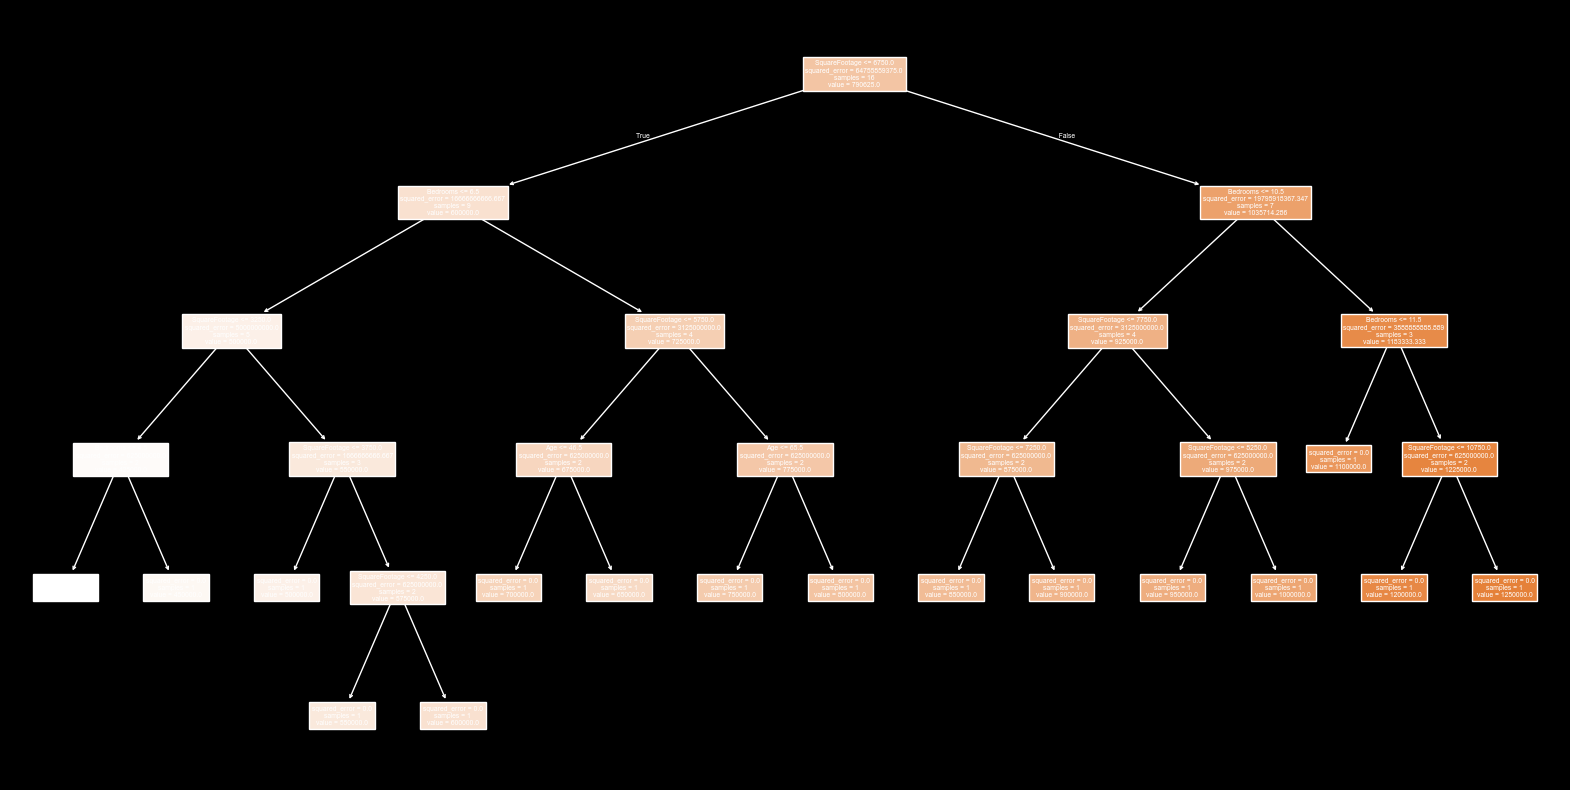

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True
)
plt.show()